In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('../results/dvs128_snn_01_to_09_batch8_3seeds_latency_beta05.txt')

In [14]:
df.head()

,representation,coding,train_size,val_size,seed,bach_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,epoch,batch_size,loss,beta
0,n_bins,latency,0.1,0.1,42.0,8.0,0.0,0.0,0.4167,0.3977,11.0,8.0,latency,0.5
1,n_bins,latency,0.3,0.1,42.0,8.0,0.0,0.0,0.6629,0.6402,23.0,8.0,latency,0.5
2,n_bins,latency,0.5,0.1,42.0,8.0,0.0,0.0,0.7348,0.6932,13.0,8.0,latency,0.5
3,n_bins,latency,0.7,0.1,42.0,8.0,0.0,0.0,0.7765,0.7386,11.0,8.0,latency,0.5
4,n_bins,latency,0.9,0.1,42.0,8.0,0.0,0.0,0.7462,0.7083,13.0,8.0,latency,0.5


In [15]:
df = df.drop(['val_rate_acc', 'val_temp_acc', 'bach_size', 'coding'], axis=1)
df['epoch'] = df['epoch'] + 1

In [16]:
df.head()

,representation,train_size,val_size,seed,test_rate_acc,test_temp_acc,epoch,batch_size,loss,beta
0,n_bins,0.1,0.1,42.0,0.4167,0.3977,12.0,8.0,latency,0.5
1,n_bins,0.3,0.1,42.0,0.6629,0.6402,24.0,8.0,latency,0.5
2,n_bins,0.5,0.1,42.0,0.7348,0.6932,14.0,8.0,latency,0.5
3,n_bins,0.7,0.1,42.0,0.7765,0.7386,12.0,8.0,latency,0.5
4,n_bins,0.9,0.1,42.0,0.7462,0.7083,14.0,8.0,latency,0.5


In [17]:
grouped_data = df.groupby(['train_size', 'representation']).agg({
    'test_rate_acc': 'mean',
    'test_temp_acc': 'mean',
    'epoch': 'mean'
}).reset_index()

In [18]:
grouped_data.head()

,train_size,representation,test_rate_acc,test_temp_acc,epoch
0,0.1,binary,0.090900,0.090900,10.666667
1,0.1,n_bins,0.433100,0.430567,10.666667
2,0.1,spike_count,0.218433,0.220967,10.666667
3,0.1,time_window,0.123733,0.123733,10.666667
4,0.1,timesurface,0.090900,0.090900,10.666667


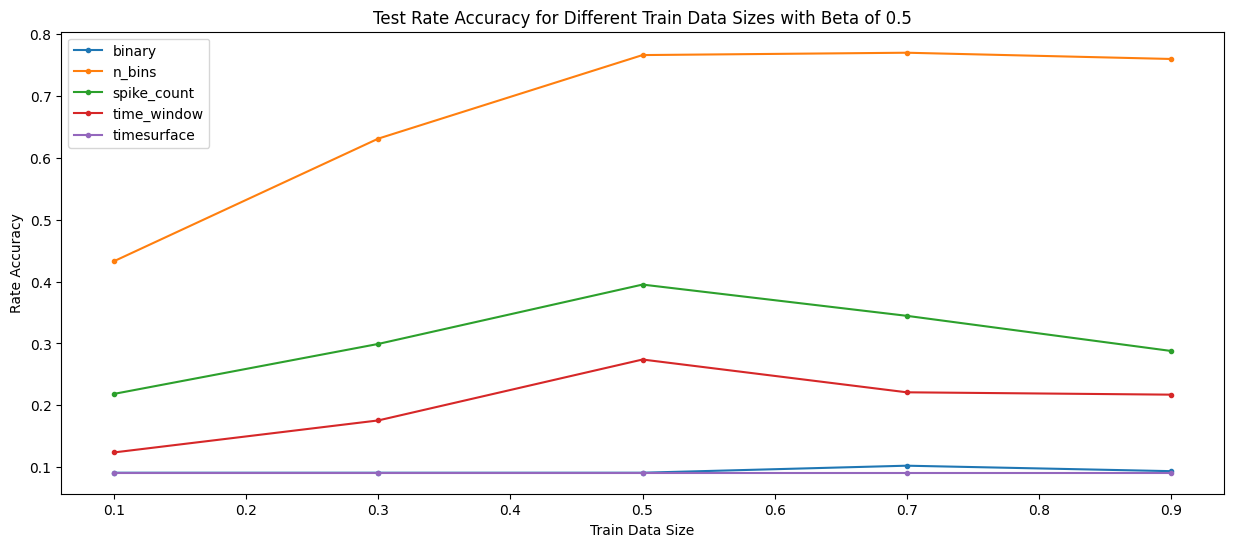

In [19]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_rate_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Rate Accuracy')
plt.title('Test Rate Accuracy for Different Train Data Sizes with Beta of 0.5')
plt.legend()
plt.show()

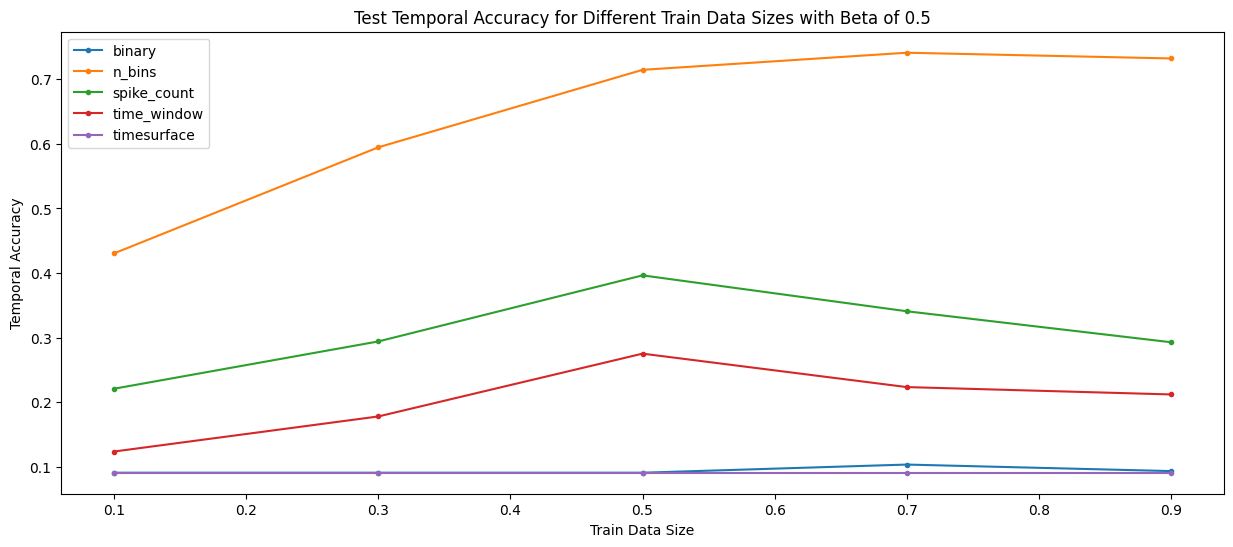

In [20]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_temp_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Temporal Accuracy')
plt.title('Test Temporal Accuracy for Different Train Data Sizes with Beta of 0.5')
plt.legend()
plt.show()

In [29]:
df = pd.read_csv('../results/dvs128_snn_01_to_09_batch8_3seeds_latency_beta09.txt')

In [30]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1

In [31]:
df.head()

,train_data_size,val_data_size,random_seed,representation,test_rate_acc,test_temp_acc,num_epochs,batch_size
0,0.1,0.1,13,binary,tensor(0.0909),tensor(0.0909),8,8
1,0.1,0.1,13,n_bins,tensor(0.2689),tensor(0.2500),8,8
2,0.1,0.1,13,spike_count,tensor(0.1477),tensor(0.1477),8,8
3,0.1,0.1,42,binary,tensor(0.0909),tensor(0.0909),10,8
4,0.1,0.1,42,n_bins,tensor(0.3864),tensor(0.3826),10,8


In [32]:
df['test_rate_acc'] = df['test_rate_acc'].str.extract(r'tensor\((.*?)\)').astype(float)
df['test_temp_acc'] = df['test_temp_acc'].str.extract(r'tensor\((.*?)\)').astype(float)

In [33]:
df.head()

,train_data_size,val_data_size,random_seed,representation,test_rate_acc,test_temp_acc,num_epochs,batch_size
0,0.1,0.1,13,binary,0.0909,0.0909,8,8
1,0.1,0.1,13,n_bins,0.2689,0.2500,8,8
2,0.1,0.1,13,spike_count,0.1477,0.1477,8,8
3,0.1,0.1,42,binary,0.0909,0.0909,10,8
4,0.1,0.1,42,n_bins,0.3864,0.3826,10,8


In [34]:
grouped_data = df.groupby(['train_data_size', 'representation']).agg({
    'test_rate_acc': 'mean',
    'test_temp_acc': 'mean',
    'num_epochs': 'mean'
}).reset_index()

In [35]:
grouped_data.head()

,train_data_size,representation,test_rate_acc,test_temp_acc,num_epochs
0,0.1,binary,0.090900,0.090900,8.666667
1,0.1,n_bins,0.363222,0.351856,8.666667
2,0.1,spike_count,0.204533,0.205800,8.666667
3,0.2,binary,0.093000,0.093000,21.555556
4,0.2,n_bins,0.538711,0.511367,21.555556


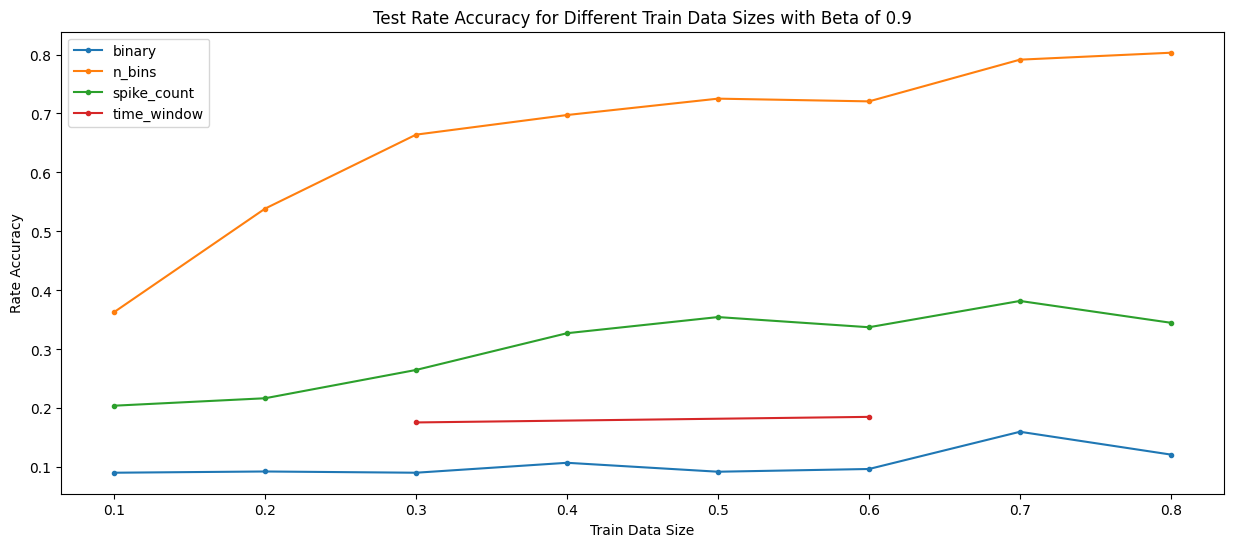

In [36]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_data_size'], rep_data['test_rate_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Rate Accuracy')
plt.title('Test Rate Accuracy for Different Train Data Sizes with Beta of 0.9')
plt.legend()
plt.show()

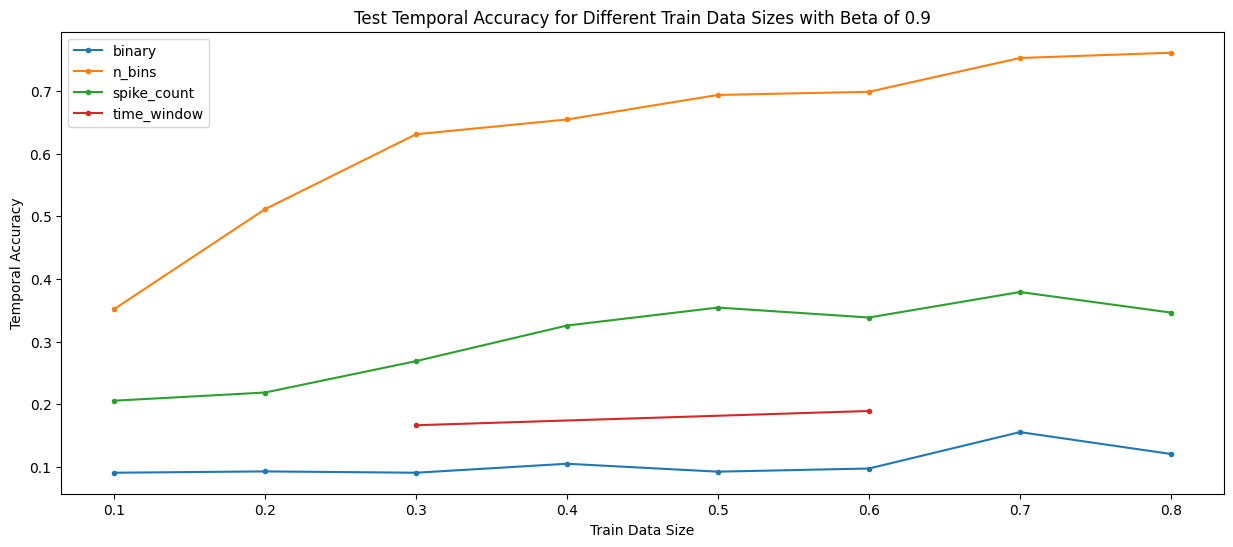

In [37]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_data_size'], rep_data['test_temp_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Temporal Accuracy')
plt.title('Test Temporal Accuracy for Different Train Data Sizes with Beta of 0.9')
plt.legend()
plt.show()

In [38]:
df = pd.read_csv("../results/dvs128_snn_09_batch8_latency_beta09.txt")

In [39]:
df.head()

,train_data_size,val_data_size,random_seed,representation,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,num_epochs,batch_size
0,0.9,0.1,13,binary,0.0,0.0,tensor(0.0985),tensor(0.0985),11,8
1,0.9,0.1,13,n_bins,0.0,0.0,tensor(0.7197),tensor(0.7045),11,8
2,0.9,0.1,13,time_window,0.0,0.0,tensor(0.1591),tensor(0.1591),11,8
3,0.9,0.1,42,binary,0.0,0.0,tensor(0.0909),tensor(0.0909),13,8
4,0.9,0.1,42,n_bins,0.0,0.0,tensor(0.7462),tensor(0.7083),13,8


In [40]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1

In [41]:
df['test_rate_acc'] = df['test_rate_acc'].str.extract(r'tensor\((.*?)\)').astype(float)
df['test_temp_acc'] = df['test_temp_acc'].str.extract(r'tensor\((.*?)\)').astype(float)

In [42]:
df.head()

,train_data_size,val_data_size,random_seed,representation,test_rate_acc,test_temp_acc,num_epochs,batch_size
0,0.9,0.1,13,binary,0.0985,0.0985,12,8
1,0.9,0.1,13,n_bins,0.7197,0.7045,12,8
2,0.9,0.1,13,time_window,0.1591,0.1591,12,8
3,0.9,0.1,42,binary,0.0909,0.0909,14,8
4,0.9,0.1,42,n_bins,0.7462,0.7083,14,8


In [43]:
grouped_data = df.groupby(['representation']).agg({
    'test_rate_acc': ['mean', 'std'],
    'test_temp_acc': ['mean', 'std'],
    'num_epochs': 'mean'
}).reset_index()

In [44]:
grouped_data.head()

representation test_rate_acc           test_temp_acc           num_epochs
                          mean       std          mean       std       mean
0         binary      0.091744  0.002533      0.091744  0.002533  18.444444
1         n_bins      0.787033  0.042076      0.754611  0.039961  18.444444
2    spike_count      0.378820  0.088963      0.372740  0.088541  20.400000
3    time_window      0.239900  0.063935      0.239889  0.063485  18.444444

C:\Users\osvat\AppData\Local\Temp\ipykernel_21696\2999479027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_21696\2999479027.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


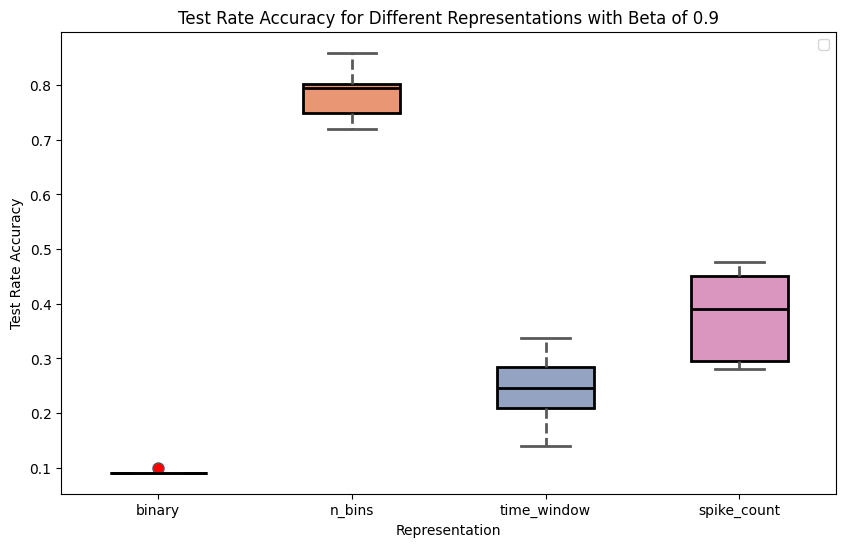

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_rate_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Rate Accuracy')
ax.set_title('Test Rate Accuracy for Different Representations with Beta of 0.9')
ax.legend()
plt.show()

C:\Users\osvat\AppData\Local\Temp\ipykernel_21696\296180814.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_21696\296180814.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


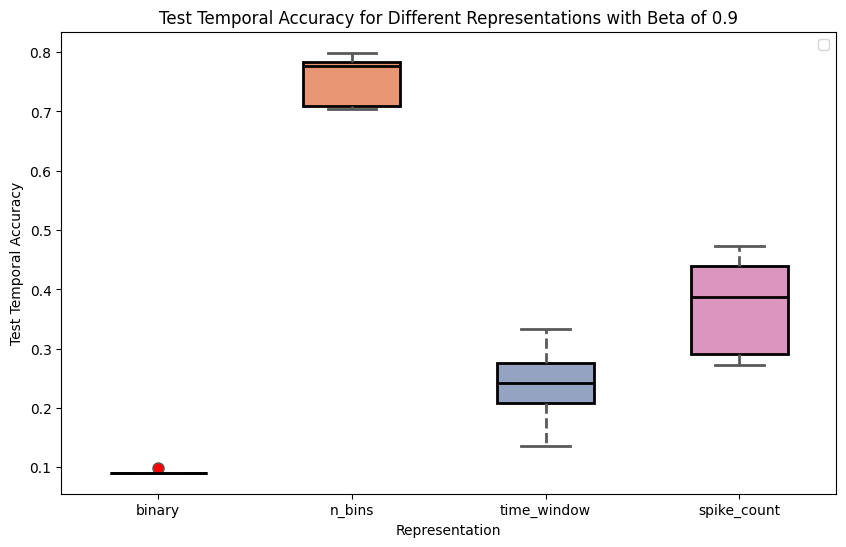

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_temp_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Temporal Accuracy')
ax.set_title('Test Temporal Accuracy for Different Representations with Beta of 0.9')
ax.legend()
plt.show()

In [47]:
grouped_data.to_csv("dvs128_snn_latency_beta09_grouped.csv")

In [3]:
df = pd.read_csv("../results/dvs128_snn_09_batch8_latency_beta05.txt")
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,latency,0.9,0.1,42,8,0,0,0.7462,0.7083,13.0,8.0,latency,0.5
1,binary,latency,0.9,0.1,42,8,0,0,0.0909,0.0909,13.0,8.0,latency,0.5
2,time_window,latency,0.9,0.1,42,8,0,0,0.2841,0.2689,13.0,8.0,latency,0.5
3,spike_count,latency,0.9,0.1,42,8,0,0,0.3674,0.3788,13.0,8.0,latency,0.5
4,timesurface,latency,0.9,0.1,42,8,0,0,0.0909,0.0909,13.0,8.0,latency,0.5


In [4]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,latency,0.9,0.1,42,8,0.7462,0.7083,14.0,8.0,latency,0.5
1,binary,latency,0.9,0.1,42,8,0.0909,0.0909,14.0,8.0,latency,0.5
2,time_window,latency,0.9,0.1,42,8,0.2841,0.2689,14.0,8.0,latency,0.5
3,spike_count,latency,0.9,0.1,42,8,0.3674,0.3788,14.0,8.0,latency,0.5
4,timesurface,latency,0.9,0.1,42,8,0.0909,0.0909,14.0,8.0,latency,0.5


In [5]:
df = df.drop(['batch_size.1', 'loss.1', 'beta'], axis=1)
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs
0,n_bins,latency,0.9,0.1,42,8,0.7462,0.7083,14.0
1,binary,latency,0.9,0.1,42,8,0.0909,0.0909,14.0
2,time_window,latency,0.9,0.1,42,8,0.2841,0.2689,14.0
3,spike_count,latency,0.9,0.1,42,8,0.3674,0.3788,14.0
4,timesurface,latency,0.9,0.1,42,8,0.0909,0.0909,14.0


C:\Users\osvat\AppData\Local\Temp\ipykernel_19288\352526334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_19288\352526334.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


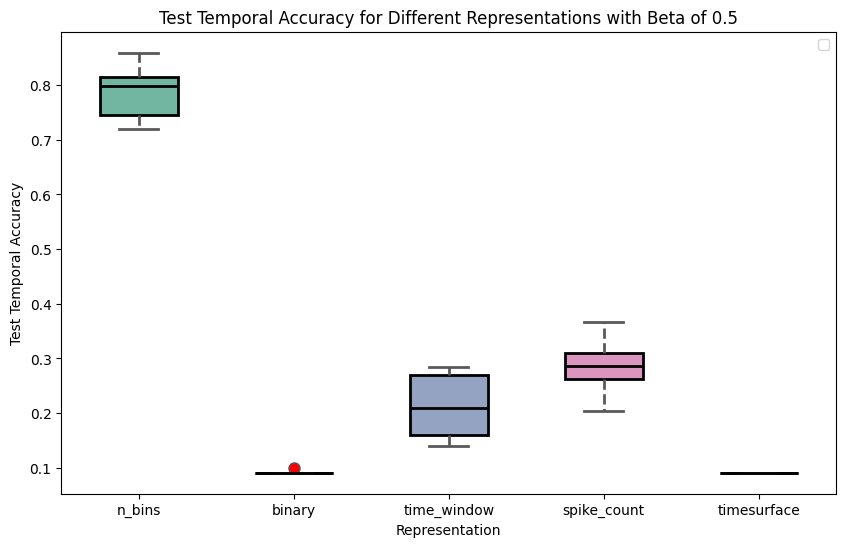

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_rate_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Temporal Accuracy')
ax.set_title('Test Temporal Accuracy for Different Representations with Beta of 0.5')
ax.legend()
plt.show()

In [7]:
grouped_data = df.groupby(['representation']).agg({
    'test_rate_acc': ['mean', 'std'],
    'test_temp_acc': ['mean', 'std'],
    'num_epochs': 'mean'
}).reset_index()
grouped_data.head()

representation test_rate_acc           test_temp_acc           num_epochs
                          mean       std          mean       std       mean
0         binary      0.092420  0.003399      0.092420  0.003399       17.6
1         n_bins      0.787860  0.055654      0.757560  0.047026       17.6
2    spike_count      0.285975  0.066666      0.287875  0.071896       15.0
3    time_window      0.212120  0.064038      0.209840  0.063052       17.6
4    timesurface      0.090900  0.000000      0.090900  0.000000       14.0

In [8]:
grouped_data = grouped_data.round(2)
grouped_data.head()

representation test_rate_acc       test_temp_acc       num_epochs
                          mean   std          mean   std       mean
0         binary          0.09  0.00          0.09  0.00       17.6
1         n_bins          0.79  0.06          0.76  0.05       17.6
2    spike_count          0.29  0.07          0.29  0.07       15.0
3    time_window          0.21  0.06          0.21  0.06       17.6
4    timesurface          0.09  0.00          0.09  0.00       14.0

In [9]:
grouped_data.to_csv("dsv_128_snn_latency_beta05_grouped.csv")